Import and Setup

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

Data Loading and Preprocessing

In [2]:
train_df = pd.read_csv("/content/sign_mnist_train.csv.zip")
test_df = pd.read_csv("/content/sign_mnist_test.csv.zip")
X_train = train_df.drop("label",axis=1).values
y_train = train_df["label"].values
X_test= test_df.drop("label",axis=1).values
y_test = test_df["label"].values
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0
y_train = to_categorical(y_train, num_classes=25)
y_test = to_categorical(y_test, num_classes=25)
X_train,X_val,y_train,y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
    )
print(X_train.shape)

(21964, 28, 28, 1)


 Model Definition and Compilation



In [3]:
def build_vgg_style():
  inputs = Input(shape=(28,28,1))
  x = Conv2D(32,(3,3),padding='same',activation='relu')(inputs)
  x = BatchNormalization()(x)
  x = Conv2D(32,(3,3),padding='same',activation='relu')(x)
  x = BatchNormalization()(x)
  x = MaxPooling2D()(x)

  x = Conv2D(64,(3,3),padding='same',activation='relu')(x)
  x = BatchNormalization()(x)
  x = Conv2D(64,(3,3),padding='same',activation='relu')(x)
  x = BatchNormalization()(x)
  x = MaxPooling2D()(x)

  x = Conv2D(128,(3,3),padding='same',activation='relu',name="last_conv")(x)
  x = BatchNormalization()(x)
  x = Conv2D(128,(3,3),padding='same',activation='relu')(x)
  x = BatchNormalization()(x)
  x = MaxPooling2D()(x)

  x = Flatten()(x)

  x = Dense(256,activation='relu')(x)
  x = Dropout(0.5)(x)

  output = Dense(25,activation='softmax')(x)

  model = Model(inputs,output)

  return model

model = build_vgg_style()

model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 589,817 (2.25 MB)

 Trainable params: 588,921 (2.25 MB)

 Non-trainable params: 896 (3.50 KB)

 Model Training

In [4]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=20,
    batch_size=64
)

Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.5904 - loss: 1.4711 - val_accuracy: 0.1532 - val_loss: 3.0451
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9485 - loss: 0.1957 - val_accuracy: 0.9984 - val_loss: 0.0495
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9859 - loss: 0.0665 - val_accuracy: 0.9998 - val_loss: 0.0058
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9940 - loss: 0.0316 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9959 - loss: 0.0206 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 6/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9981 - loss: 0.0123 - val_accuracy: 1.0000 - val_loss: 6.8160e-04
Epoch 7/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9991 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 6.1475e-04
Epoch 8/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9992 - loss: 0.0067 - val_ac

Model Evaluation and Classification Report


In [5]:
loss,acc=model.evaluate(X_test,y_test)

print("Test Accuracy:",acc)

preds = model.predict(X_test)

y_pred = np.argmax(preds,axis=1)
y_true = np.argmax(y_test,axis=1)

print(classification_report(y_true,y_pred))


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9674 - loss: 0.1334
Test Accuracy: 0.9673731327056885
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       331
           1       1.00      0.95      0.98       432
           2       1.00      1.00      1.00       310
           3       1.00      1.00      1.00       245
           4       0.97      0.96      0.96       498
           5       1.00      1.00      1.00       247
           6       0.94      0.99      0.96       348
           7       1.00      0.95      0.98       436
           8       0.99      0.99      0.99       288
          10       0.91      0.99      0.95       331
          11       1.00      1.00      1.00       209
          12       0.92      1.00      0.96       394
          13       1.00      0.81      0.89       291
          14       1.00      1.00      1.00       246
          15       0.99      1.00      

Grad-CAM Function Definition

In [6]:
def gradcam(model, image, layer_name="last_conv"):

  grad_model = Model(
      [model.inputs],
      [model.get_layer(layer_name).output, model.output]
  )

  with tf.GradientTape() as tape:

    conv_output, prediction = grad_model(
        tf.expand_dims(image,axis=0)
    )
    class_idx = tf.argmax(prediction[0])
    loss = prediction[:,class_idx]

  grads = tape.gradient(loss, conv_output)
  pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
  conv_output = conv_output[0]
  heatmap = conv_output @ pooled_grads[..., tf.newaxis]
  heatmap = tf.squeeze(heatmap)
  heatmap = tf.maximum(heatmap,0)
  heatmap /= tf.reduce_max(heatmap)
  return heatmap.numpy()

Grad-CAM Visualization

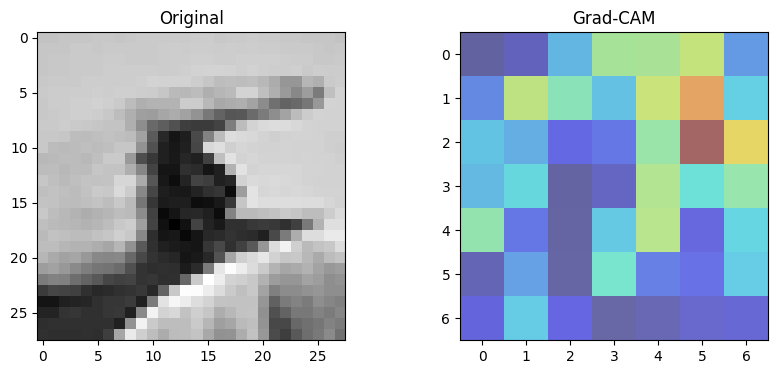

In [9]:
sample = X_test[0]

heatmap = gradcam(model, sample)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample.squeeze(), cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(sample.squeeze(), cmap='gray')
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Grad-CAM")

plt.show()




Integrated Gradients Function Definition

In [10]:
def integrated_gradients(
    model,
    image,
    baseline=None,
    steps=50):
  if baseline is None:
    baseline = np.zeros_like(image)

  interpolated_image = [
      baseline + (float(i)/steps)*(image-baseline)
      for i in range(steps+1)
  ]
  interpolated_image = tf.convert_to_tensor(
      np.array(interpolated_image),
      dtype=tf.float32
  )
  with tf.GradientTape() as tape:
    tape.watch(interpolated_image)
    preds = model(interpolated_image)
    target_class = tf.argmax(preds[-1])
    outputs = preds[:, target_class]

  grads = tape.gradient(
      outputs,
      interpolated_image
  )
  avg_grads = tf.reduce_mean(
      grads,
      axis=0
  )
  integrated_grads = (image-baseline)*avg_grads
  return integrated_grads.numpy()

Integrated Gradients Visualization

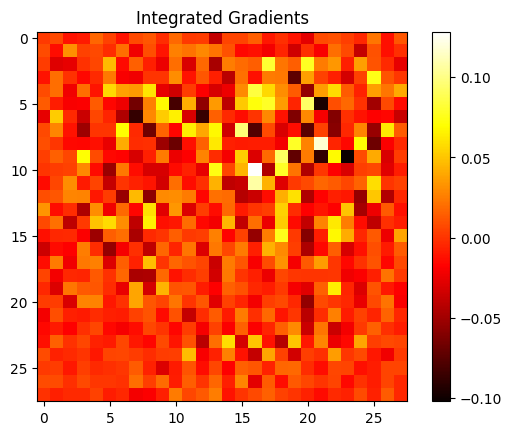

In [11]:
attr = integrated_gradients(
    model,
    X_test[0]
)
plt.imshow(
    attr.squeeze(),
    cmap='hot'
)
plt.colorbar()
plt.title("Integrated Gradients")
plt.show()

 Install LIME

In [12]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4a10054ac13be7b978de72ff75afeb4612420152d8785d9d9284be3252d16ce2
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Import LIME Libraries


In [13]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

Initialize LIME Explainer

In [14]:
explainer = lime_image.LimeImageExplainer()

Define Prediction Function for LIME

In [15]:
def predict_fn(image):
  gray = np.mean(image, axis=-1)
  gray = gray.reshape(-1,28,28,1)
  return model.predict(gray)

Generate LIME Explanation

In [16]:
sample = X_test[0]
rgb_sample = np.repeat(sample, 3, axis=-1)
explanation = explainer.explain_instance(
    rgb_sample,
    predict_fn,
    top_labels=1,
    num_samples=1000
)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1

LIME Visualization

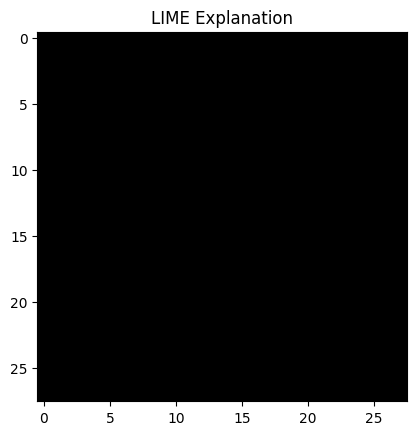

In [17]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    hide_rest=False
)
plt.imshow(
    mark_boundaries(temp/255.0, mask)
)
plt.title("LIME Explanation")
plt.show()